# EDA: Hotel Booking Demand

## Источник данных и причина выбора

Для проекта был выбран датасет **Hotel Booking Demand** с Kaggle:
https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand

Этот датасет был выбран по нескольким причинам. Во-первых, он хорошо подходит под задачу машинного обучения, потому что целевая переменная здесь естественно формулируется как бинарная классификация (будет бронирование отменено или нет). Во-вторых, датасет достаточно большой по объёму и содержит как числовые, так и категориальные признаки, что позволяет провести полноценный EDA, подготовку данных и сравнение нескольких моделей. В-третьих, задача выглядит практически осмысленной, потому что прогноз отмены бронирования может быть полезен для управления загрузкой отеля и планирования выручки.


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use('default')
sns.set_theme(style='whitegrid')

DATA_PATH = Path('..') / 'data' / 'raw' / 'hotel_bookings.csv'
df = pd.read_csv(DATA_PATH)
df.shape

(119390, 32)

Исходный датасет содержит 119390 строк и 32 колонки.

In [6]:
df.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

Короткая расшифровка столбцов датасета:

| Колонка | Что означает |
|---|---|
| hotel | Тип отеля: городской или курортный. |
| is_canceled | Целевая переменная: 1, если бронь отменена, и 0, если нет. |
| lead_time | Сколько дней прошло между бронированием и датой заезда. |
| arrival_date_year | Год заезда. |
| arrival_date_month | Месяц заезда. |
| arrival_date_week_number | Номер недели года на момент заезда. |
| arrival_date_day_of_month | День месяца на момент заезда. |
| stays_in_weekend_nights | Количество ночей на выходных. |
| stays_in_week_nights | Количество ночей в будние дни. |
| adults | Количество взрослых гостей. |
| children | Количество детей. |
| babies | Количество младенцев. |
| meal | Тип питания, выбранный при бронировании. |
| country | Страна клиента. |
| market_segment | Канал и сегмент бронирования. |
| distribution_channel | Канал, через который пришло бронирование. |
| is_repeated_guest | Признак повторного гостя. |
| previous_cancellations | Количество предыдущих отмен у клиента. |
| previous_bookings_not_canceled | Количество предыдущих бронирований без отмен. |
| reserved_room_type | Тип номера, который был забронирован. |
| assigned_room_type | Тип номера, который был фактически выдан. |
| booking_changes | Количество изменений в бронировании. |
| deposit_type | Тип депозита при бронировании. |
| agent | Идентификатор агента, если бронирование шло через посредника. |
| company | Идентификатор компании, если бронирование связано с компанией. |
| days_in_waiting_list | Сколько дней бронь находилась в листе ожидания. |
| customer_type | Тип клиента: transient, contract и т.д. |
| adr | Средняя стоимость номера за день. |
| required_car_parking_spaces | Количество необходимых парковочных мест. |
| total_of_special_requests | Количество специальных запросов от клиента. |
| reservation_status | Финальный статус бронирования, используется как leakage и в модель не идет. |
| reservation_status_date | Дата финального статуса бронирования, тоже leakage и в модель не идет. |

По сути в датасете есть и поведенческие признаки, и признаки условий бронирования, и временной контекст.

In [8]:
missing = df.isna().sum().sort_values(ascending=False)
missing.head(10)

company                      112593
agent                         16340
country                         488
children                          4
arrival_date_month                0
arrival_date_week_number          0
hotel                             0
is_canceled                       0
stays_in_weekend_nights           0
arrival_date_day_of_month         0
dtype: int64

In [9]:
duplicates = df.duplicated().sum()
zero_guests = ((df['adults'] + df['children'].fillna(0) + df['babies']) == 0).sum()
zero_nights = ((df['stays_in_weekend_nights'] + df['stays_in_week_nights']) == 0).sum()
negative_adr = (df['adr'] < 0).sum()

pd.Series(
    {
        'duplicates': duplicates,
        'zero_guests_rows': zero_guests,
        'zero_nights_rows': zero_nights,
        'negative_adr_rows': negative_adr,
    }
)

duplicates           31994
zero_guests_rows       180
zero_nights_rows       715
negative_adr_rows        1
dtype: int64

В данных есть пропуски, и они сконцентрированы в `company`, `agent`, `country` и `children`. Кроме того, обнаруживаются дубликаты и заведомо некорректные строки: бронирования без гостей, бронирования без ночей и строка с отрицательным `adr`. Все это в дальнейшем будет обработано в preprocessing.py

Выбранные решения по очистке:

1. `children` заполняется нулём, потому что отсутствие значения здесь принимается за отсутствие детей в бронировании.
2. `country` заполняется значением `Unknown`, чтобы не терять строки и при этом явно пометить неизвестную страну.
3. `agent` и `company` заполняются нулём как признаком отсутствия соответствующего посредника.
4. дубликаты удаляются, чтобы не смещать обучение.
5. строки с нулевыми гостями, нулевыми ночами и отрицательным `adr` удаляются как некорректные.

In [10]:
target_share = df['is_canceled'].value_counts(normalize=True).rename('share')
target_share

is_canceled
0    0.629584
1    0.370416
Name: share, dtype: float64

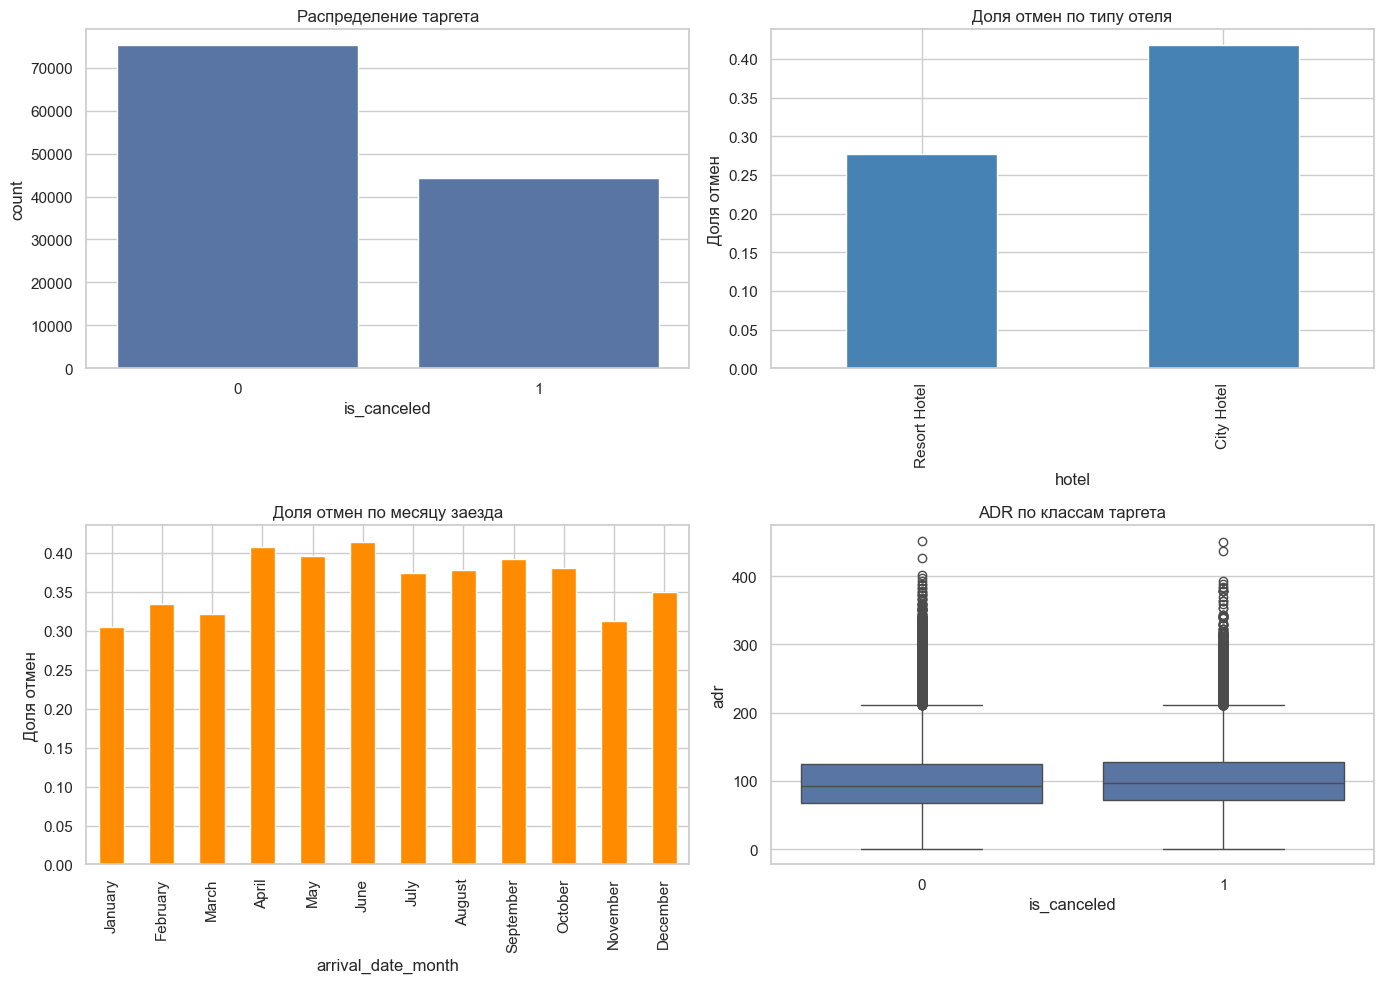

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='is_canceled', ax=axes[0, 0])
axes[0, 0].set_title('Распределение таргета')
axes[0, 0].set_xlabel('is_canceled')

df.groupby('hotel')['is_canceled'].mean().sort_values().plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Доля отмен по типу отеля')
axes[0, 1].set_ylabel('Доля отмен')

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df.groupby('arrival_date_month')['is_canceled'].mean().reindex(month_order).plot(kind='bar', ax=axes[1, 0], color='darkorange')
axes[1, 0].set_title('Доля отмен по месяцу заезда')
axes[1, 0].set_ylabel('Доля отмен')

sns.boxplot(data=df[df['adr'].between(0, 500)], x='is_canceled', y='adr', ax=axes[1, 1])
axes[1, 1].set_title('ADR по классам таргета')
axes[1, 1].set_xlabel('is_canceled')

plt.tight_layout()
plt.show()

По таргету видно, что классы умеренно несбалансированы: доля отменённых бронирований заметно ниже, но не настолько мала, чтобы задача превращалась в экстремально несбалансированную классификацию. Это одна из причин, почему в качестве основной метрики разумно использовать `F1`, а не только accuracy.

Графики также показывают, что отмена явно зависит от типа отеля, месяца заезда и цены (`adr`). Видно, что признаки бронирования несут осмысленный сигнал для модели.

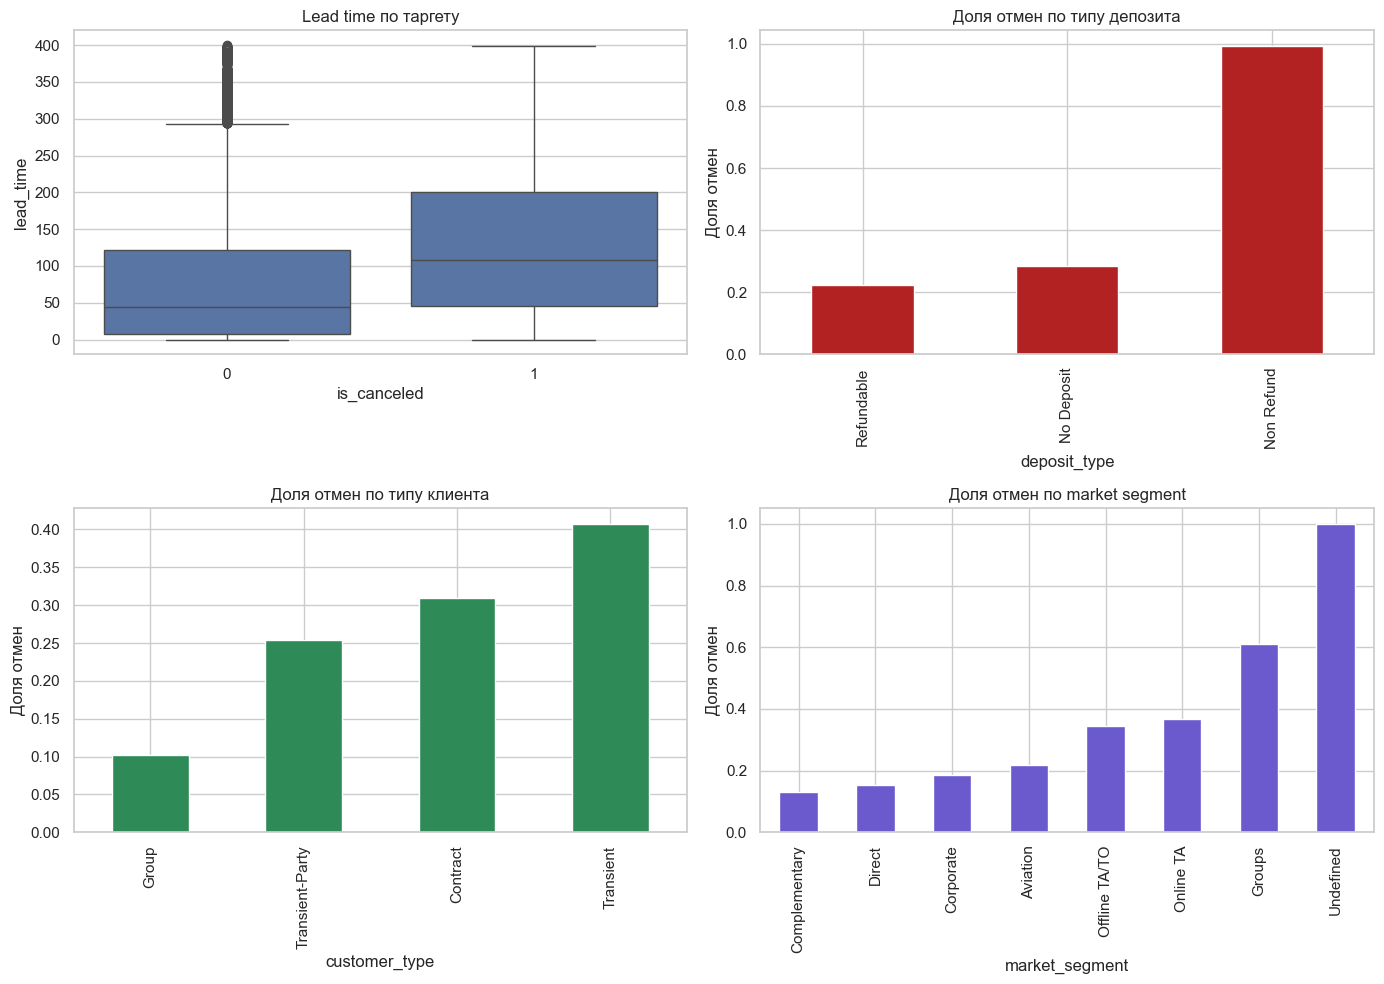

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df[df['lead_time'] <= 400], x='is_canceled', y='lead_time', ax=axes[0, 0])
axes[0, 0].set_title('Lead time по таргету')

df.groupby('deposit_type')['is_canceled'].mean().sort_values().plot(kind='bar', ax=axes[0, 1], color='firebrick')
axes[0, 1].set_title('Доля отмен по типу депозита')
axes[0, 1].set_ylabel('Доля отмен')

df.groupby('customer_type')['is_canceled'].mean().sort_values().plot(kind='bar', ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Доля отмен по типу клиента')
axes[1, 0].set_ylabel('Доля отмен')

df.groupby('market_segment')['is_canceled'].mean().sort_values().plot(kind='bar', ax=axes[1, 1], color='slateblue')
axes[1, 1].set_title('Доля отмен по market segment')
axes[1, 1].set_ylabel('Доля отмен')

plt.tight_layout()
plt.show()

Какие признаки могут влиять на отмену брони:

1. `lead_time` - чем раньше бронирование сделано относительно даты заезда, тем выше вероятность отмены.
2. `deposit_type` - у категории `Non Refund` доля отмен почти максимальная, это делает этот признак очень информативным.
3. `customer_type` и `market_segment` - показывают сильные различия по доле отмен.

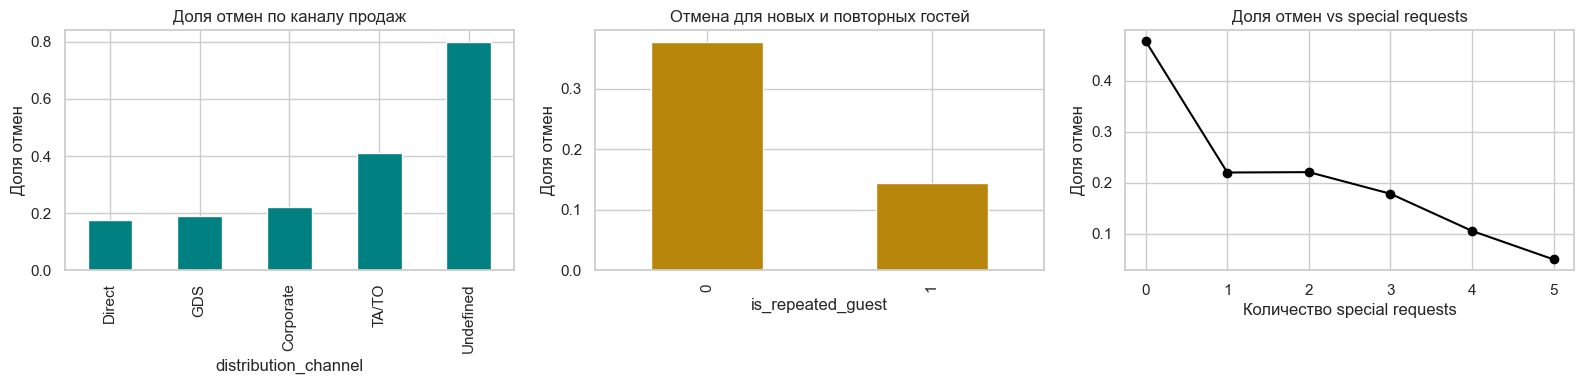

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df.groupby('distribution_channel')['is_canceled'].mean().sort_values().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Доля отмен по каналу продаж')
axes[0].set_ylabel('Доля отмен')

df.groupby('is_repeated_guest')['is_canceled'].mean().plot(kind='bar', ax=axes[1], color='darkgoldenrod')
axes[1].set_title('Отмена для новых и повторных гостей')
axes[1].set_ylabel('Доля отмен')

df.groupby('total_of_special_requests')['is_canceled'].mean().plot(marker='o', ax=axes[2], color='black')
axes[2].set_title('Доля отмен vs special requests')
axes[2].set_ylabel('Доля отмен')
axes[2].set_xlabel('Количество special requests')

plt.tight_layout()
plt.show()

1) повторные гости отменяют бронирования заметно реже, чем новые клиенты
2) с ростом числа `special_requests` доля отмен снижается

Это вполне логично: клиенты, которые конкретнее формулируют свои пожелания, вероятно, чаще реально планируют поездку.

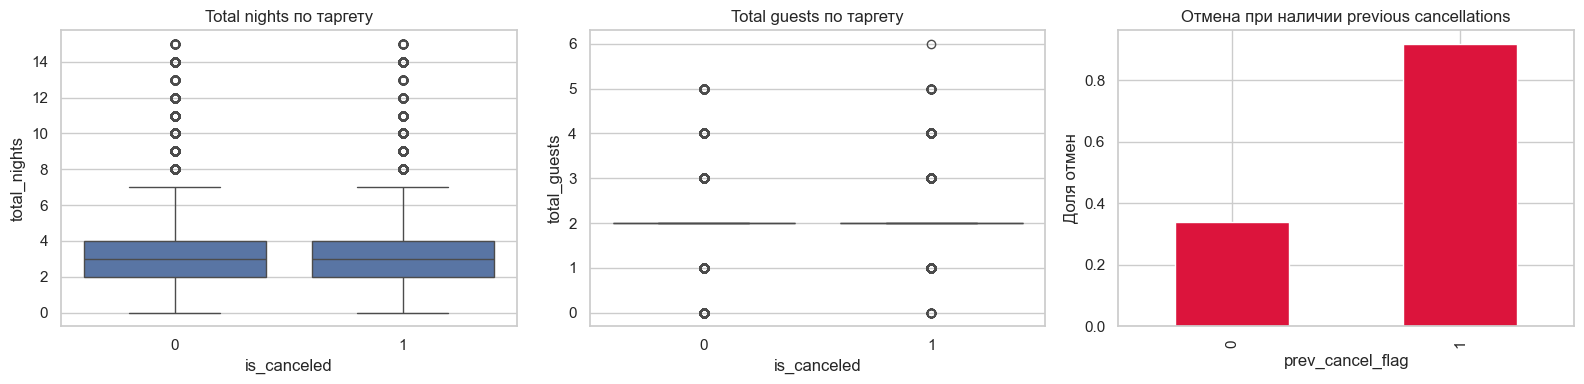

In [14]:
df_with_flags = df.copy()
df_with_flags['children'] = df_with_flags['children'].fillna(0)
df_with_flags['total_guests'] = df_with_flags['adults'] + df_with_flags['children'] + df_with_flags['babies']
df_with_flags['total_nights'] = df_with_flags['stays_in_weekend_nights'] + df_with_flags['stays_in_week_nights']
df_with_flags['prev_cancel_flag'] = (df_with_flags['previous_cancellations'] > 0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df_with_flags[df_with_flags['total_nights'] <= 15], x='is_canceled', y='total_nights', ax=axes[0])
axes[0].set_title('Total nights по таргету')

sns.boxplot(data=df_with_flags[df_with_flags['total_guests'] <= 6], x='is_canceled', y='total_guests', ax=axes[1])
axes[1].set_title('Total guests по таргету')

df_with_flags.groupby('prev_cancel_flag')['is_canceled'].mean().plot(kind='bar', ax=axes[2], color='crimson')
axes[2].set_title('Отмена при наличии previous cancellations')
axes[2].set_ylabel('Доля отмен')

plt.tight_layout()
plt.show()

Признаки `total_guests` и `total_nights` удобнее интерпретировать, чем исходные колонки по отдельности. Флаг по `previous_cancellations` - если у клиента уже были отмены в прошлом, вероятность новой отмены резко возрастает.

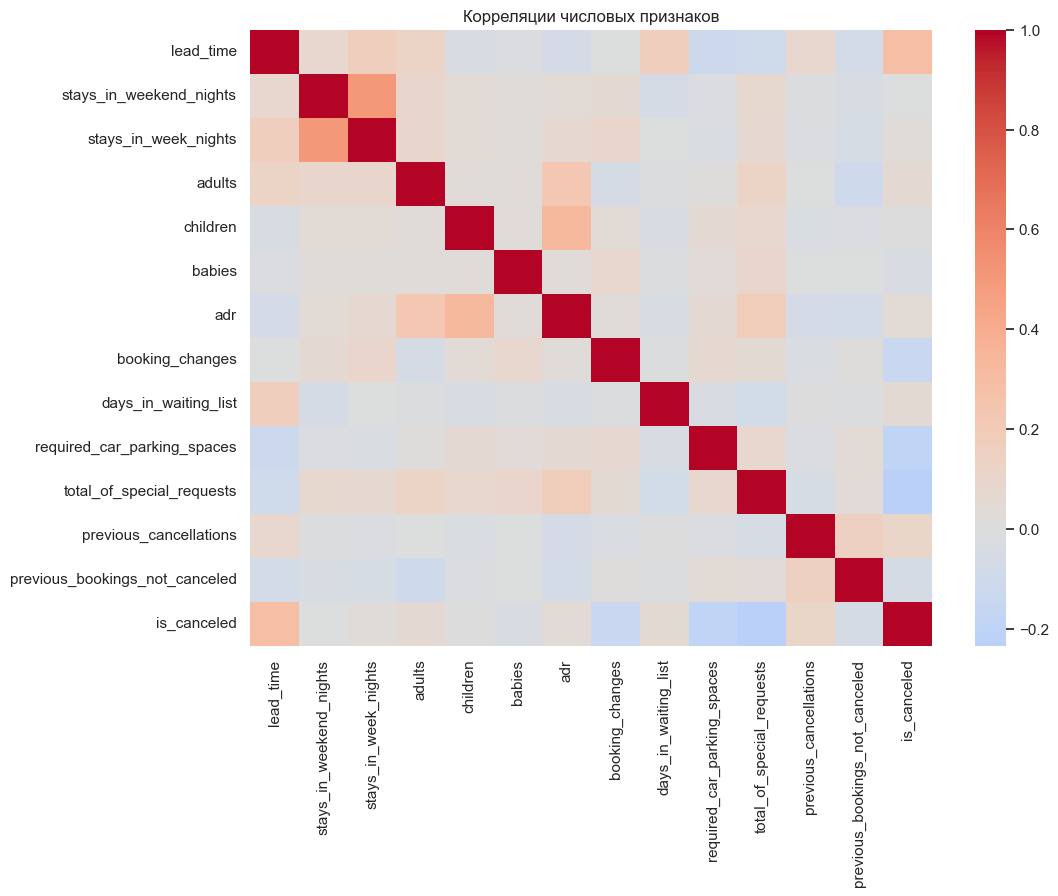

is_canceled                       1.000000
lead_time                         0.293123
previous_cancellations            0.110133
adults                            0.060017
days_in_waiting_list              0.054186
adr                               0.047557
stays_in_week_nights              0.024765
children                          0.005036
stays_in_weekend_nights          -0.001791
babies                           -0.032491
previous_bookings_not_canceled   -0.057358
booking_changes                  -0.144381
required_car_parking_spaces      -0.195498
total_of_special_requests        -0.234658
Name: is_canceled, dtype: float64

In [15]:
numeric_cols = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
    'babies', 'adr', 'booking_changes', 'days_in_waiting_list',
    'required_car_parking_spaces', 'total_of_special_requests',
    'previous_cancellations', 'previous_bookings_not_canceled', 'is_canceled'
]

corr = df.assign(children=df['children'].fillna(0))[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Корреляции числовых признаков')
plt.show()

corr['is_canceled'].sort_values(ascending=False)

Наиболее заметная положительная связь с таргетом у `lead_time` и `previous_cancellations`, наиболее заметная отрицательная - у `total_of_special_requests`, `required_car_parking_spaces` и `booking_changes`. Это обосновывается тем, что клиент, который вносит изменения в бронь, оставляет запросы и действительно доходит до деталей поездки, чаще сохраняет бронирование.

## Утечка данных

Признаки `reservation_status` и `reservation_status_date` нельзя использовать в модели, потому что они описывают уже фактический исход бронирования. Если оставить их в данных, модель получит информацию из будущего и метрики будут завышены. Поэтому эти колонки удаляются на этапе preprocessing.

## Выводы

1. Датасет достаточно большой и разнообразный по типам признаков, поэтому хорошо подходит для задачи бинарной классификации
2. В данных есть пропуски, дубликаты и несколько типов некорректных строк, поэтому нужна очистка
3. На отмену брони заметно влияют как числовые признаки (`lead_time`, `adr`, `previous_cancellations`, `total_of_special_requests`), так и категориальные (`deposit_type`, `market_segment`, `distribution_channel`, `customer_type`, `hotel`)
4. Наблюдения из EDA напрямую оправдывают feature engineering: агрегаты `total_guests`, `total_nights`, `adr_per_person`, а также признаки наличия детей, агента и компании выглядят осмысленно
5. Признаки `reservation_status` и `reservation_status_date` исключаются, так как они описывают фактический исход бронирования